In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import copy
from dotenv import load_dotenv
import json
import pandas as pd



Used device: cuda


In [ ]:
!pip install opencv-python
!pip install scikit-learn
!pip install seaborn
!pip install python-dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [seaborn]m3/4 [seaborn]


In [ ]:
!wget https://cloud.vermeille.fr/s/36dOOpeBn7aIvcZ/download -O download.zip

!unzip download.zip &> /dev/null

!wget https://raw.githubusercontent.com/Vermeille/leaderboard/refs/heads/master/client/leaderboard_client.py

## Charger le TOKEN du fichier .env

In [32]:



load_dotenv()  

TOKEN = os.getenv("LEADERBOARD_TOKEN")

if TOKEN:
    os.environ['LEADERBOARD_TOKEN'] = TOKEN
    print(" Token chargé depuis .env")
else:
    print(" Aucun token trouvé dans .env — submit_training/test sera désactivé")


 Token chargé depuis .env


## Config générale

In [33]:
DATA_ROOT = "./FCUNIST"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR = os.path.join(DATA_ROOT, "test")

# Get class names
classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print(f"Classes ({len(classes)}): {classes}")



Classes (15): ['batman', 'blackpanther', 'blackwidow', 'cthulhu', 'doctorstrange', 'dracula', 'gamora', 'harrypotter', 'hulk', 'ironman', 'shrek', 'spiderman', 'storm', 'wanda', 'wonderwoman']


Visualizing random samples from the training dataset:


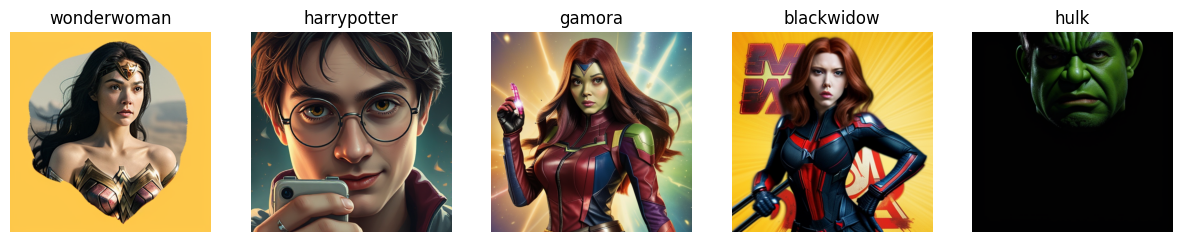

In [34]:
def visualize_samples(root_dir, classes, num_samples=5):
    plt.figure(figsize=(15, 3))

    selected_classes = np.random.choice(classes, min(len(classes), num_samples), replace=False)
    
    for i, class_name in enumerate(selected_classes):
        class_dir = os.path.join(root_dir, class_name)
        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if image_files:
     
            img_name = np.random.choice(image_files)
            img_path = os.path.join(class_dir, img_name)
            
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.subplot(1, num_samples, i+1)
                plt.imshow(img)
                plt.title(class_name)
                plt.axis('off')
    plt.show()

print("Visualizing random samples from the training dataset:")
visualize_samples(TRAIN_DIR, classes)

In [128]:


torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Used device: {device}")

# Hyperparamètres
IMG_SIZE = 224  # ResNet expects 224x224
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-5
WEIGHT_DECAY = 1e-2


Used device: cuda


## Leaderboard client

In [129]:

LB_AVAILABLE = False
try:
    import leaderboard_client as lb
    LB_AVAILABLE = True
    print("Setup complet : dataset + leaderboard_client + token chargé")


except ImportError:
    print("leaderboard_client non trouvé. "
          "Les fonctions de logging/soumission seront désactivées.")



Setup complet : dataset + leaderboard_client + token chargé


In [130]:
# Dataset Class
class FCUNISTDataset(Dataset):
    def __init__(self, root_dir, classes=None, transform=None):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform
        self.image_paths = []
        self.labels = []
        

        has_subdirs = False
        if self.classes:

            for c in self.classes:
                if os.path.isdir(os.path.join(root_dir, c)):
                    has_subdirs = True
                    break
        
        if has_subdirs and self.classes:
            for class_idx, class_name in enumerate(self.classes):
                class_dir = os.path.join(self.root_dir, class_name)
                if not os.path.isdir(class_dir):
                    continue
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(class_dir, img_name))
                        self.labels.append(class_idx)
        else:

            if os.path.isdir(root_dir):
                for img_name in os.listdir(root_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(root_dir, img_name))
                        self.labels.append(-1)
        
        print(f"Loaded {len(self.image_paths)} images from {root_dir}")
                    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        if image is None:

            print(f"Warning: Could not load image {img_path}")
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = image.astype(np.float32) / 255.0
            image = torch.from_numpy(image).permute(2, 0, 1)
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label



In [131]:
class FlexibleCNN(nn.Module):
    def __init__(self, num_classes):
        super(FlexibleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x


Classes (15): ['batman', 'blackpanther', 'blackwidow', 'cthulhu', 'doctorstrange', 'dracula', 'gamora', 'harrypotter', 'hulk', 'ironman', 'shrek', 'spiderman', 'storm', 'wanda', 'wonderwoman']
Loaded 8587 images from ./FCUNIST/train
Loaded 8587 images from ./FCUNIST/train
Loaded 8587 images from ./FCUNIST/train
Loaded 584 images from ./FCUNIST/test
Training samples: 6869
Validation samples: 1718
Test samples: 584
Loading ResNet50 with pretrained weights...
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(

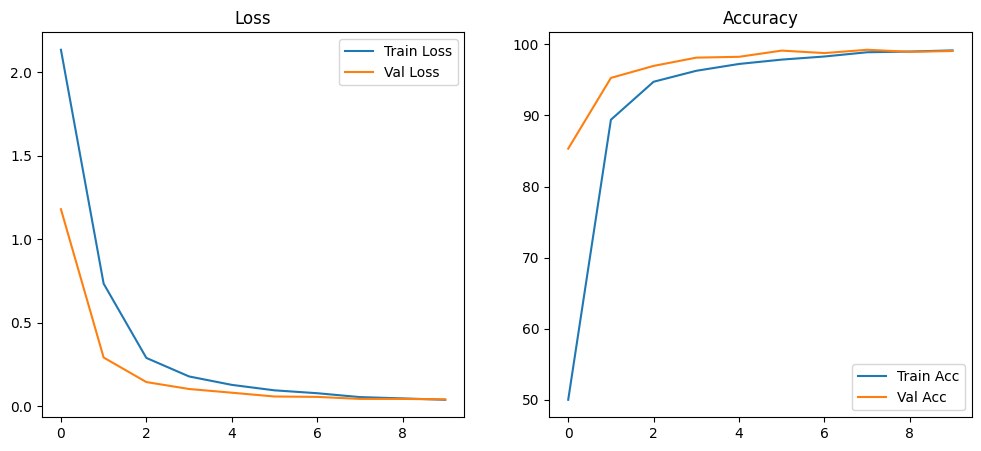

In [ ]:
# Training Function
def train_model(model, train_loader, val_loader, epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3, verbose=True)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    print("training will start")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    
            if (i + 1) % 50 == 0:
                batch_loss = loss.item()
                batch_acc = 100 * (predicted == labels).sum().item() / labels.size(0)
                print(f"Epoch [{epoch+1}/{epochs}], Batch [{i+1}/{len(train_loader)}], Loss: {batch_loss:.4f}, Acc: {batch_acc:.2f}%")
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_epoch_loss = val_loss / len(val_loader)
        val_epoch_acc = 100 * correct / total
        val_losses.append(val_epoch_loss)
        val_accs.append(val_epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}%")
        
        # Step the scheduler
        scheduler.step(val_epoch_loss)
        
        # Save best model
        if val_epoch_acc > best_acc:
            best_acc = val_epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_model.pth")
            print(f"New best model saved with accuracy: {best_acc:.2f}%")

        if LB_AVAILABLE and "LEADERBOARD_TOKEN" in os.environ:
            log_info = {
                "num_epochs": EPOCHS,
                "lr": optimizer.param_groups[0]["lr"],
                "batch_size": BATCH_SIZE,
            "weight_decay": WEIGHT_DECAY,
            "epoch": epoch,
            }
            try:
                lb.submit_training(
                    val_epoch_acc,     
                    val_epoch_loss,    
                    log_info,
                    tag=f"Epoch {epoch}"
                )
            except Exception as e:
                print(f"Erreur submit_training: {e}")

            

    print(f"Training complete. Best val Acc: {best_acc:.2f}%")
    model.load_state_dict(best_model_wts)
    return train_losses, val_losses, train_accs, val_accs

if __name__ == "__main__":

    classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
    print(f"Classes ({len(classes)}): {classes}")


    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


    full_dataset = FCUNISTDataset(TRAIN_DIR, classes, transform=None) # No transform yet
    
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    

    indices = torch.randperm(len(full_dataset)).tolist()
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    train_dataset = FCUNISTDataset(TRAIN_DIR, classes, transform=train_transform)
    train_dataset = torch.utils.data.Subset(train_dataset, train_indices)
    
    val_dataset = FCUNISTDataset(TRAIN_DIR, classes, transform=val_transform)
    val_dataset = torch.utils.data.Subset(val_dataset, val_indices)
    
  
    test_dataset = FCUNISTDataset(TEST_DIR, classes=classes, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
 
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")


    print("Loading ResNet50 with pretrained weights...")
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(classes))
    
    model = model.to(device)
    print(model)


    history = train_model(model, train_loader, val_loader, epochs=EPOCHS)
    

    torch.save(model.state_dict(), "fcunist_model.pth")
    print("Model saved to fcunist_model.pth")

   
    train_losses, val_losses, train_accs, val_accs = history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.title('Loss')

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend()
    plt.title('Accuracy')
    plt.savefig('training_history.png')
    print("Training history plot saved to training_history.png")


    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #print("\nClassification Report:")
    #print(classification_report(all_labels, all_preds, target_names=classes))

In [ ]:
class FCUNISTDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        for class_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(self.root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_dir, img_name))
                    self.labels.append(class_idx)
                    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
        else:
            # Default transform if none provided
            image = image.astype(np.float32) / 255.0
            image = torch.from_numpy(image).permute(2, 0, 1)
            
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

# Define transforms
# We resize to 224x224 for ResNet50
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = FCUNISTDataset(TRAIN_DIR, classes, transform=transform)
test_dataset = FCUNISTDataset(TEST_DIR, classes, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 8587
Test samples: 0


In [70]:
# Initialize ResNet50 model
print("Loading ResNet50 with pretrained weights...")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Modify the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(classes))

model = model.to(device)
print(model)


Loading ResNet50 with pretrained weights...
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [71]:
# Load checkpoint
checkpoint_path = "./best_model.pth"

# Ensure model is initialized (in case previous cells weren't run)
if 'model' not in globals():
    print("Initializing model architecture...")
    # Re-run necessary setup if missing
    if 'classes' not in globals():
        DATA_ROOT = "./FCUNIST"
        TRAIN_DIR = os.path.join(DATA_ROOT, "train")
        classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
    
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(classes))
    model = model.to(device)

if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    try:
        # Try loading as direct state dict
        state_dict = torch.load(checkpoint_path, map_location=device)
        # Handle case where state_dict might be inside a 'model_state_dict' key but loaded directly
        if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
             model.load_state_dict(state_dict['model_state_dict'])
             print("Model loaded successfully (from checkpoint dict).")
        else:
             model.load_state_dict(state_dict)
             print("Model loaded successfully (direct state dict).")
    except Exception as e:
        print(f"Error loading model: {e}")
else:
    print(f"Checkpoint file not found at {checkpoint_path}")

Loading checkpoint from ./best_model.pth


/tmp/ipykernel_1284567/298678163.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=device)


Model loaded successfully (direct state dict).


In [ ]:
class FCUNISTTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []

        if not LB_AVAILABLE or "LEADERBOARD_TOKEN" not in os.environ:
            print("leaderboard_client ou LEADERBOARD_TOKEN manquant. "
                "Impossible de submit_test.")
            return

        
        # Check if directory exists
        if not os.path.exists(root_dir):
            print(f"Error: Directory {root_dir} does not exist.")
        else:
            # Load all images directly from the root_dir (flat structure)
            for img_name in os.listdir(root_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(root_dir, img_name))
            self.image_paths.sort() # Sort for consistent ordering
                    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Could not read image {img_path}")
            # Return a dummy image or handle error
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
            
        # Return image and filename (since we don't have labels)
        return image, os.path.basename(img_path)

# Re-initialize test dataset for flat structure
print(f"Looking for test images in: {TEST_DIR}")
test_dataset_eval = FCUNISTTestDataset(TEST_DIR, transform=transform)
test_loader_eval = DataLoader(test_dataset_eval, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test samples found: {len(test_dataset_eval)}")

if len(test_dataset_eval) > 0:
    model.eval()

    all_preds_leaderboard = {}   # <-- pour le leaderboard (dict de dict)
    all_filenames = []           # pour garder l’ordre
    top1_preds = []              # indices de la classe la plus probable (pour affichage/CSV)

    print("Running inference...")
    with torch.no_grad():
        for images, filenames in test_loader_eval:
            images = images.to(device)
            outputs = model(images)             # logits [B, num_classes]
            logits_batch = outputs.cpu().tolist()  # -> list[list[float]]

            for fname, logit_vec in zip(filenames, logits_batch):
                # Dictionnaire {nom_de_classe: score}
                pred_dict = {
                    classes[i]: float(logit_vec[i])
                    for i in range(len(classes))
                }
                all_preds_leaderboard[fname] = pred_dict

                # Top-1 pour cette image
                top1_idx = int(np.argmax(logit_vec))
                top1_preds.append(top1_idx)
                all_filenames.append(fname)

    print("Inference complete.")
    
    # Affichage des 20 premières prédictions (top-1)
    print("\nSample Predictions (top-1):")
    print(f"{'Filename':<40} | {'Predicted Class'}")
    print("-" * 60)
    for fname, idx in list(zip(all_filenames, top1_preds))[:20]:
        pred_class = classes[idx]
        print(f"{fname:<40} | {pred_class}")

    # Sauvegarde CSV (comme avant, avec top-1)
    results_df = pd.DataFrame({
        'filename': all_filenames,
        'prediction': [classes[p] for p in top1_preds]
    })
    save_path_csv = os.path.join(DATA_ROOT, "test_predictions.csv")
    results_df.to_csv(save_path_csv, index=False)
    print(f"\nAll predictions saved to {save_path_csv}")

    # sauvegarde JSON au format leaderboard
    save_path_json = os.path.join(DATA_ROOT, "test_predictions.json")
    with open(save_path_json, "w") as f:
        json.dump(all_preds_leaderboard, f)
    print(f"Predictions JSON saved to {save_path_json}")


    print( all_preds_leaderboard)
    # Soumission leaderboard, avec le BON format
    try:
        lb.submit_test(all_preds_leaderboard)
        print("✅ Test soumis au leaderboard.")
    except Exception as e:
        print(f"Erreur submit_test: {e}")

else:
    print("No images found in test directory. Please check the path and file extensions.")


Looking for test images in: ./FCUNIST/test
Test samples found: 584
Running inference...
Inference complete.

Sample Predictions (top-1):
Filename                                 | Predicted Class
------------------------------------------------------------
0018779557827b636f9c622783755185.png     | dracula
00a3ad50c565a465b8cb355cb9086c86.png     | doctorstrange
00a47cb704ecb8fd2c18b85e337e1793.png     | batman
00a48d08edf7e56a12b6cc1ca05bd5cf.png     | wanda
014b59556031680d8d5678da99706710.png     | ironman
019503cd2f298e58df89401bfa0a761b.png     | hulk
02a917f8c46f61b3b09e02687e7a7561.png     | shrek
031172f05f2b7af67f8e14da6791a765.png     | gamora
03c9d7296798551542b54e9b4800ff72.png     | hulk
0416f4ba340370fd72d6b55aaa553dd2.png     | spiderman
041f57d8d64cc0715457dd51bae507bb.png     | hulk
04dd4eb9b5bac24e3c76798d89bc47fc.png     | dracula
04e2c0a28cb9ccffd363ba1d9983bce2.png     | storm
05673808affbd8c1b9569d7da593d243.png     | gamora
06084bebe7be0da7f36a1ce733724710.png   